# 01 · Preparación y selección de factores
Geovanny Andrés Velasco Ospina **Fase CRISP-DM:** Entendimiento de los datos y Preparación de datos

In [1]:
# 1.0 Instalación de librerías perfilamiento de datos
!pip install -q ydata-profiling

In [2]:
# 1.1 Montar Google Drive y fijar la carpeta del proyecto
from google.colab import drive
drive.mount('/content/drive')

import os
RUTA_PROYECTO = '/content/drive/MyDrive/Proyecto Final'
os.chdir(RUTA_PROYECTO)

RUTA_SALIDAS = os.path.join(RUTA_PROYECTO, 'salidas_python')
os.makedirs(RUTA_SALIDAS, exist_ok=True)

ARCHIVO_ARFF = 'BD_final_python.arff'
print('Carpeta de trabajo :', os.getcwd())
print('Carpeta de salidas :', RUTA_SALIDAS)
print('¿Existe el .arff?  :', os.path.exists(ARCHIVO_ARFF))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carpeta de trabajo : /content/drive/.shortcut-targets-by-id/1ltR8i-osdZp85e6jPUTbQPV2HV0E8hjD/Proyecto Final
Carpeta de salidas : /content/drive/MyDrive/Proyecto Final/salidas_python
¿Existe el .arff?  : True


In [3]:
# 1.2 Versiones del entorno
import sys
import numpy as np
import pandas as pd
import sklearn
import joblib

print('python      :', sys.version.split()[0])
print('pandas      :', pd.__version__)
print('scikit-learn:', sklearn.__version__)
print('joblib      :', joblib.__version__)
print('numpy       :', np.__version__)

pd.set_option('display.max_columns', 50)            # Mostrar todas las columnas al imprimir
pd.set_option('display.float_format', '{:,.2f}'.format)  # Números con separador de miles y 2 decimales

python      : 3.13.15
pandas      : 2.2.3
scikit-learn: 1.6.1
joblib      : 1.6.0
numpy       : 2.1.3


In [4]:
# 1.3 Carga del .arff y decodificación de textos
from scipy.io import arff                           # Lector oficial de archivos ARFF (formato de Weka)

datos, meta = arff.loadarff(ARCHIVO_ARFF)           # datos = registros; meta = definición de atributos
df_raw = pd.DataFrame(datos)                        # Convierte los registros a DataFrame

tipo_arff = dict(zip(meta.names(), meta.types()))   # Tipo declarado en el .arff (numeric/nominal)
print('Tipos declarados en el .arff:', tipo_arff)   # Evidencia: 'marca' viene como numeric
print('\ndtypes al cargar (ANTES de corregir):\n', df_raw.dtypes.value_counts())  # Verás float64 y object

cols_bytes = [c for c in df_raw.columns if df_raw[c].dtype == object]  # Columnas nominales (llegan en bytes)
for c in cols_bytes:                                # Recorre cada columna nominal
    df_raw[c] = (df_raw[c].str.decode('utf-8')      # b'F' -> 'F' (bytes a texto)
                          .str.strip()              # Quita espacios sobrantes: 'Calle ' -> 'Calle'
                          .replace('?', np.nan))    # '?' es el faltante del ARFF -> NaN real

print('\nColumnas decodificadas:', cols_bytes)      # Nominales ya convertidas a texto
print('Forma:', df_raw.shape)                       # Esperado: (17603, 18)
df_raw.head()                                       # Ya no debe aparecer ningún b'...'

Tipos declarados en el .arff: {'id_asesor': 'numeric', 'genero_asesor': 'nominal', 'edad_asesor': 'numeric', 'tipo_vinculacion': 'nominal', 'nacionalidad_asesor': 'nominal', 'total_dias_absentismo': 'numeric', 'id_tienda': 'numeric', 'tipo_ubicacion_tienda': 'nominal', 'marca': 'numeric', 'zona_comercial': 'nominal', 'cantidad_cajas': 'numeric', 'metros_cuadrados_tienda': 'numeric', 'mes_venta': 'nominal', 'anio_venta': 'numeric', 'venta_t_1': 'numeric', 'venta_t_2': 'numeric', 'venta_t_3': 'numeric', 'valor_venta_asesor_mes_t': 'numeric'}

dtypes al cargar (ANTES de corregir):
 float64    12
object      6
Name: count, dtype: int64

Columnas decodificadas: ['genero_asesor', 'tipo_vinculacion', 'nacionalidad_asesor', 'tipo_ubicacion_tienda', 'zona_comercial', 'mes_venta']
Forma: (17603, 18)


,id_asesor,genero_asesor,edad_asesor,tipo_vinculacion,nacionalidad_asesor,total_dias_absentismo,id_tienda,tipo_ubicacion_tienda,marca,zona_comercial,cantidad_cajas,metros_cuadrados_tienda,mes_venta,anio_venta,venta_t_1,venta_t_2,venta_t_3,valor_venta_asesor_mes_t
0,"1,673.00",F,29.08,INDEF,EXTRANJERO,0.00,70.00,CENTRO COMERCIAL,2.00,MEDELLIN,1.00,86.28,junio,"2,024.00",0.00,0.00,0.00,0.00
1,"1,097.00",M,26.00,INDEF,EXTRANJERO,0.00,66.00,CENTRO COMERCIAL,3.00,MEDELLIN,2.00,165.00,agosto,"2,024.00",0.00,0.00,0.00,0.00
2,807.00,M,33.00,INDEF,COLOMBIA,0.00,4.00,CENTRO COMERCIAL,2.00,BOGOTA,3.00,190.25,febrero,"2,026.00",0.00,0.00,0.00,0.00
3,"2,364.00",F,29.08,INDEF,EXTRANJERO,0.00,151.00,CENTRO COMERCIAL,2.00,EXTERIOR,2.00,207.17,junio,"2,025.00",0.00,0.00,0.00,0.00
4,"2,364.00",F,29.08,INDEF,EXTRANJERO,0.00,151.00,CENTRO COMERCIAL,2.00,EXTERIOR,2.00,207.17,julio,"2,025.00",0.00,0.00,0.00,0.00


In [5]:
# 1.3b Tipos de datos: solo category y float64
MESES = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio',
         'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']   # Orden del calendario

CATEGORICAS = ['id_asesor', 'id_tienda', 'genero_asesor', 'tipo_vinculacion',
               'nacionalidad_asesor', 'tipo_ubicacion_tienda', 'marca', 'zona_comercial']  # Etiquetas

for c in CATEGORICAS:                               # Para cada etiqueta...
    if pd.api.types.is_numeric_dtype(df_raw[c]):    # ...si viene como número (IDs, marca)
        df_raw[c] = df_raw[c].astype('int64').astype(str)   # la paso a texto: 2.0 -> '2'
    df_raw[c] = df_raw[c].astype('category')        # y luego a category

df_raw['mes_venta'] = pd.Categorical(df_raw['mes_venta'].str.lower().str.strip(),
                                     categories=MESES, ordered=True)   # Mes en orden de calendario

NUMERICAS = df_raw.columns.difference(CATEGORICAS + ['mes_venta'])     # Todo lo demás es número
df_raw[NUMERICAS] = df_raw[NUMERICAS].astype('float64')                # Todos los números a float64

df_raw.dtypes.astype(str).value_counts()            # Resumen: cuántas columnas de cada tipo

,count
category,9
float64,9


In [6]:
#Consulta del tipo de dato
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17603 entries, 0 to 17602
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   id_asesor                 17603 non-null  category
 1   genero_asesor             17603 non-null  category
 2   edad_asesor               17603 non-null  float64 
 3   tipo_vinculacion          17603 non-null  category
 4   nacionalidad_asesor       17603 non-null  category
 5   total_dias_absentismo     17603 non-null  float64 
 6   id_tienda                 17603 non-null  category
 7   tipo_ubicacion_tienda     17603 non-null  category
 8   marca                     17603 non-null  category
 9   zona_comercial            17603 non-null  category
 10  cantidad_cajas            17603 non-null  float64 
 11  metros_cuadrados_tienda   17603 non-null  float64 
 12  mes_venta                 17603 non-null  category
 13  anio_venta                17603 non-null  floa

In [7]:
# 1.4 Índice temporal y orden
df = df_raw.copy()                                  # Aquí nace "df": copia de trabajo (df_raw queda intacta)

mes_num = df['mes_venta'].cat.codes + 1             # Posición del mes en el calendario: enero=1 ... diciembre=12
idx_mes = df['anio_venta'].astype(int) * 12 + mes_num   # Número de mes continuo entre años
df['t'] = (idx_mes - idx_mes.min()).astype('float64')   # Contador: abril 2024 = 0 ... agosto 2026 = 28

df = df.sort_values(['id_asesor', 't']).reset_index(drop=True)  # Ordena: cada asesor, sus meses en orden
print('t mínimo:', df['t'].min(), '| t máximo:', df['t'].max())  # Esperado: 0.0 y 28.0
df[['id_asesor', 'anio_venta', 'mes_venta', 't', 'venta_t_1', 'valor_venta_asesor_mes_t']].head(6)

t mínimo: 0.0 | t máximo: 28.0


,id_asesor,anio_venta,mes_venta,t,venta_t_1,valor_venta_asesor_mes_t
0,1,"2,025.00",enero,9.00,0.00,"890,252.86"
1,1,"2,025.00",febrero,10.00,"890,252.86","193,193.33"
2,10,"2,025.00",abril,12.00,0.00,"971,677.25"
3,10,"2,025.00",mayo,13.00,"971,677.25","406,987.00"
4,100,"2,024.00",mayo,1.00,0.00,"39,295,780.99"
5,100,"2,024.00",junio,2.00,"39,295,780.99","78,929,041.46"


In [8]:
# 1.5 Validación de la base
print('Forma:', df.shape)
print('Nulos totales:', int(df.isna().sum().sum()))
print('Filas duplicadas idénticas:', df_raw.duplicated().sum())
print('Duplicados (asesor, mes):', df.duplicated(subset=['id_asesor', 't']).sum())

faltan = sorted(set(range(29)) - set(df['t'].astype(int)))
print('Meses en la base:', df['t'].nunique(), '| Meses faltantes:', faltan)

print('Asesores:', df['id_asesor'].nunique(), '| Tiendas:', df['id_tienda'].nunique())
print('\nRegistros por año:\n', df.groupby('anio_venta').size())

Forma: (17603, 19)
Nulos totales: 0
Filas duplicadas idénticas: 0
Duplicados (asesor, mes): 0
Meses en la base: 29 | Meses faltantes: []
Asesores: 2237 | Tiendas: 151

Registros por año:
 anio_venta
2,024.00    5523
2,025.00    7598
2,026.00    4482
dtype: int64


In [9]:
# 1.6 Perfilamiento automático (ydata-profiling)
from ydata_profiling import ProfileReport           # Librería de perfilamiento automático

perfil = ProfileReport(df_raw,                      # Base antes de las reglas de calidad
                       title='Perfilamiento BD ventas asesor-mes',  # Título del reporte
                       minimal=True)                # Modo liviano

ruta_html = os.path.join(RUTA_SALIDAS, 'perfilamiento_bd_ventas.html')  # Se guarda en Drive
perfil.to_file(ruta_html)                           # Genera y guarda el reporte
print('Reporte guardado en:', ruta_html)            # Confirma la ubicación


/tmp/ipykernel_54060/2945507528.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport           # Librería de perfilamiento automático


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 18/18 [00:00<00:00, 23.41it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte guardado en: /content/drive/MyDrive/Proyecto Final/salidas_python/perfilamiento_bd_ventas.html


In [10]:
# 1.7 Resumen
numericas = df_raw.select_dtypes('float64')         # Solo las columnas numéricas

resumen = pd.DataFrame({
    'Mínimo':      numericas.min(),                 # Valor más bajo
    'Mediana':     numericas.median(),              # Valor central (no lo afectan los extremos)
    'Máximo':      numericas.max(),                 # Valor más alto
    '% ceros':     (numericas == 0).mean() * 100,   # Porcentaje de registros en 0
    'Asimetría':   numericas.skew(),                # > 1: cola larga a la derecha (pocos valores muy altos)
})
resumen.round(2)                                    # Tabla redondeada a 2 decimales

,Mínimo,Mediana,Máximo,% ceros,Asimetría
edad_asesor,14.00,29.00,57.00,0.00,0.84
total_dias_absentismo,0.00,0.00,31.00,84.39,4.00
cantidad_cajas,1.00,2.00,4.00,0.00,1.13
metros_cuadrados_tienda,50.00,140.18,329.00,0.00,0.90
anio_venta,"2,024.00","2,025.00","2,026.00",0.00,0.10
venta_t_1,0.00,"22,175,891.30","466,085,581.49",18.70,1.68
venta_t_2,0.00,"16,092,726.31","466,085,581.49",25.46,1.79
venta_t_3,0.00,"12,963,858.85","396,804,111.34",29.67,1.85
valor_venta_asesor_mes_t,0.00,"33,494,929.16","466,085,581.49",0.28,1.53


In [11]:
## 2 Creación de utils.py

In [12]:
%%writefile utils.py
# utils.py — Ingeniería de características (la usan el notebook y la app)
import numpy as np                                   # Para log1p
import pandas as pd                                  # Para tablas y tipos

MESES = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio',
         'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']   # Orden del calendario
CATEGORICAS = ['genero_asesor', 'tipo_vinculacion', 'nacionalidad_asesor',
               'tipo_ubicacion_tienda', 'marca', 'zona_comercial', 'mes_venta']   # Predictores categóricos
REZAGOS = ['venta_t_1', 'venta_t_2', 'venta_t_3']    # Ventas de los 3 meses anteriores


def agregar_antiguedad(df):
    """Meses que lleva el asesor en la base (solo notebook; en la app se digita)."""
    out = df.sort_values(['id_asesor', 't']).copy()  # Orden asesor-tiempo: requisito para contar bien
    out['meses_antiguedad'] = (out.groupby('id_asesor', observed=True)  # Por cada asesor...
                                  .cumcount()        # ...cuenta sus registros previos: 0, 1, 2... (solo pasado, sin fuga)
                                  .astype('float64'))
    return out


def preparar_features(df):
    """Crea sin_hist y log de rezagos, y estandariza categorías. Misma lógica para notebook y app."""
    out = df.copy()                                  # No modifica la tabla original
    for k, col in enumerate(REZAGOS, start=1):       # Recorre venta_t_1, t_2, t_3
        venta = out[col].astype('float64')           # Asegura tipo numérico
        out[f'sin_hist_t_{k}'] = (venta == 0).astype('float64')   # 1 = sin historia ese mes; 0 = sí tiene
        out[f'log_{col}'] = np.log1p(venta)          # log(1 + venta): reduce asimetría; el 0 queda en 0
    out['marca'] = (pd.to_numeric(out['marca'].astype(str))   # '2' o 2 → 2...
                      .astype(int).astype(str))      # ...→ '2' (mismo formato en notebook y app)
    out['mes_venta'] = out['mes_venta'].astype(str).str.lower().str.strip()   # 'Diciembre ' → 'diciembre'
    for c in CATEGORICAS:                            # Estandariza cada categórica
        if c == 'mes_venta':
            out[c] = pd.Categorical(out[c], categories=MESES, ordered=True)   # Mes en orden de calendario
        else:
            out[c] = out[c].astype(str).astype('category')                   # Texto → category
    return out

Overwriting utils.py


In [13]:
# 2.1 Aplicación de las funciones
import importlib                                     # Permite recargar utils si se edita
import utils                                         # Importa nuestro archivo utils.py
importlib.reload(utils)                              # Toma siempre la última versión guardada

df_feat = utils.preparar_features(utils.agregar_antiguedad(df))   # Antigüedad + sin_hist + log + categorías

nuevas = ['meses_antiguedad', 'sin_hist_t_1', 'sin_hist_t_2', 'sin_hist_t_3',
          'log_venta_t_1', 'log_venta_t_2', 'log_venta_t_3']      # Variables creadas
print('Forma:', df_feat.shape)                       # Esperado: 17603 filas, 26 columnas (19 + 7)
df_feat[['id_asesor', 't', 'venta_t_1'] + nuevas].head(6)          # Muestra de un asesor

Forma: (17603, 26)


,id_asesor,t,venta_t_1,meses_antiguedad,sin_hist_t_1,sin_hist_t_2,sin_hist_t_3,log_venta_t_1,log_venta_t_2,log_venta_t_3
0,1,9.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00
1,1,10.00,"890,252.86",1.00,0.00,1.00,1.00,13.70,0.00,0.00
2,10,12.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00
3,10,13.00,"971,677.25",1.00,0.00,1.00,1.00,13.79,0.00,0.00
4,100,1.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00
5,100,2.00,"39,295,780.99",1.00,0.00,1.00,1.00,17.49,0.00,0.00


In [14]:
# 2.3 Verificación de sin_hist contra la historia real del panel
claves = set(zip(df_feat['id_asesor'].astype(str), df_feat['t']))   # Todos los pares (asesor, mes) que existen
filas = []                                           # Resultados por rezago
for k in (1, 2, 3):                                  # Rezagos de 1, 2 y 3 meses
    tiene_registro = pd.Series([(a, t - k) in claves  # ¿Existe el mismo asesor k meses antes?
                                for a, t in zip(df_feat['id_asesor'].astype(str), df_feat['t'])],
                               index=df_feat.index)
    sin_hist = df_feat[f'sin_hist_t_{k}'] == 1       # Nuestra regla: rezago = 0
    filas.append({
        'Rezago': f't_{k}',
        'sin_hist = 1': int(sin_hist.sum()),
        '% coincide con "sin registro previo"': f'{(sin_hist == ~tiene_registro).mean():.2%}',
        '(a) Venta 0 con registro previo': int((sin_hist & tiene_registro).sum()),
        '(b) Venta > 0 sin registro previo en la base': int((~sin_hist & ~tiene_registro).sum())})
pd.DataFrame(filas)                                  # Tabla de verificación

,Rezago,sin_hist = 1,"% coincide con ""sin registro previo""",(a) Venta 0 con registro previo,(b) Venta > 0 sin registro previo en la base
0,t_1,3291,97.40%,12,445
1,t_2,4481,95.27%,13,820
2,t_3,5222,93.30%,10,1170


In [15]:
# 2.4 Diagnóstico de los casos (b): ¿están en los primeros meses de la base?
filas_b = []                                          # Resultados por rezago
for k in (1, 2, 3):                                   # Rezagos de 1, 2 y 3 meses
    tiene_registro = pd.Series([(a, t - k) in claves  # ¿Existe el mismo asesor k meses antes?
                                for a, t in zip(df_feat['id_asesor'].astype(str), df_feat['t'])],
                               index=df_feat.index)
    caso_b = (df_feat[f'sin_hist_t_{k}'] == 0) & ~tiene_registro   # Venta > 0 sin registro previo
    inicio = df_feat['t'] < k                         # Primeros k meses de la base (sin meses previos disponibles)
    filas_b.append({
        'Rezago': f't_{k}',
        'Casos (b)': int(caso_b.sum()),
        'En los primeros meses de la base': int((caso_b & inicio).sum()),     # Explicados por datos previos a abril 2024
        'En meses posteriores (huecos)': int((caso_b & ~inicio).sum())})     # Asesor ausente un mes y luego regresa
pd.DataFrame(filas_b)                                 # Tabla de diagnóstico

,Rezago,Casos (b),En los primeros meses de la base,En meses posteriores (huecos)
0,t_1,445,445,0
1,t_2,820,820,0
2,t_3,1170,1170,0


In [16]:
# 2.5 Tabla de variables para el modelo
NUMERICAS_MODELO = ['edad_asesor', 'total_dias_absentismo', 'cantidad_cajas',
                    'metros_cuadrados_tienda', 'meses_antiguedad',
                    'log_venta_t_1', 'log_venta_t_2', 'log_venta_t_3']
BINARIAS_MODELO = ['sin_hist_t_1', 'sin_hist_t_2', 'sin_hist_t_3']
CATEGORICAS_MODELO = utils.CATEGORICAS
OBJETIVO = 'valor_venta_asesor_mes_t'

tipo_real = {'edad_asesor': 'Numérica discreta*', 'total_dias_absentismo': 'Numérica discreta',
             'cantidad_cajas': 'Numérica discreta', 'metros_cuadrados_tienda': 'Numérica continua',
             'meses_antiguedad': 'Numérica discreta', 'log_venta_t_1': 'Numérica continua',
             'log_venta_t_2': 'Numérica continua', 'log_venta_t_3': 'Numérica continua',
             'mes_venta': 'Categórica ordinal/cíclica'}

tabla_vars = pd.DataFrame(
    [{'Variable': v, 'Tipo real': tipo_real[v], 'Tratamiento': 'Tal cual'} for v in NUMERICAS_MODELO] +
    [{'Variable': v, 'Tipo real': 'Binaria (0/1)', 'Tratamiento': 'Tal cual'} for v in BINARIAS_MODELO] +
    [{'Variable': v, 'Tipo real': tipo_real.get(v, 'Categórica nominal'),
      'Tratamiento': 'One-hot (en Pipeline)'} for v in CATEGORICAS_MODELO])
tabla_vars['dtype'] = [str(df_feat[v].dtype) for v in tabla_vars['Variable']]

print('Predictores:', len(tabla_vars))
tabla_vars

Predictores: 18


,Variable,Tipo real,Tratamiento,dtype
0,edad_asesor,Numérica discreta*,Tal cual,float64
1,total_dias_absentismo,Numérica discreta,Tal cual,float64
2,cantidad_cajas,Numérica discreta,Tal cual,float64
3,metros_cuadrados_tienda,Numérica continua,Tal cual,float64
4,meses_antiguedad,Numérica discreta,Tal cual,float64
5,log_venta_t_1,Numérica continua,Tal cual,float64
6,log_venta_t_2,Numérica continua,Tal cual,float64
7,log_venta_t_3,Numérica continua,Tal cual,float64
8,sin_hist_t_1,Binaria (0/1),Tal cual,float64
9,sin_hist_t_2,Binaria (0/1),Tal cual,float64


In [17]:
# 3. Partición temporal: entrenamiento 2024–2025 | prueba 2026

In [18]:
# 3.2 Partición temporal
es_train = df_feat['anio_venta'] <= 2025            # True = 2024 o 2025 (entrenamiento)
train = df_feat[es_train].copy()                    # Entrenamiento: el "pasado"
test = df_feat[~es_train].copy()                    # Prueba: 2026, el "futuro" (examen final)

PREDICTORES = NUMERICAS_MODELO + BINARIAS_MODELO + CATEGORICAS_MODELO   # Los 18 de la Celda 2.5
X_train, y_train = train[PREDICTORES], train[OBJETIVO]   # Lo que el modelo ve y lo que debe predecir
X_test, y_test = test[PREDICTORES], test[OBJETIVO]       # Igual, pero para el examen final

print('Entrenamiento:', X_train.shape, f'({len(train) / len(df_feat):.1%})')   # Esperado: (13121, 18) ≈ 74,5 %
print('Prueba       :', X_test.shape, f'({len(test) / len(df_feat):.1%})')     # Esperado: (4482, 18) ≈ 25,5 %
print('t entrenamiento:', int(train['t'].min()), 'a', int(train['t'].max()))    # Esperado: 0 a 20
print('t prueba       :', int(test['t'].min()), 'a', int(test['t'].max()))      # Esperado: 21 a 28
print('¿Meses en común?:', train['t'].max() >= test['t'].min())                 # Esperado: False (sin traslape)

nuevos = set(test['id_asesor']) - set(train['id_asesor'])   # Asesores que solo aparecen en 2026
print('Asesores en prueba que el modelo nunca vio:', len(nuevos),
      f"de {test['id_asesor'].nunique()}")          # El modelo deberá predecirlos sin conocerlos
print('Diciembres en entrenamiento:', int((train['mes_venta'] == 'diciembre').sum()),
      '| en prueba:', int((test['mes_venta'] == 'diciembre').sum()))   # La prueba (ene–ago) no tiene diciembre

Entrenamiento: (13121, 18) (74.5%)
Prueba       : (4482, 18) (25.5%)
t entrenamiento: 0 a 20
t prueba       : 21 a 28
¿Meses en común?: False
Asesores en prueba que el modelo nunca vio: 208 de 976
Diciembres en entrenamiento: 1917 | en prueba: 0


## 4 Dummies para la selección de factores
**Objetivo:** convertir las 7 categóricas en columnas 0/1 para que los métodos de selección puedan usarlas.
**Sustento:** correlaciones, árbol y regresión logística requieren X numéricas. Se usa pd.get_dummies SOLO sobre entrenamiento. Estas dummies son solo para la selección

In [19]:
# 4.1 Dummies para la selección de factores (solo entrenamiento)
X_dum = pd.get_dummies(X_train,                     # Solo entrenamiento (R4)
                       columns=CATEGORICAS_MODELO,  # Las 7 categóricas
                       prefix_sep='=',              # Nombres legibles: 'zona_comercial=MEDELLIN'
                       dtype='float64')             # Columnas 0/1 como float64 (tu criterio de tipos)

print('Antes:', X_train.shape, '| Después:', X_dum.shape)    # 18 columnas → más columnas por las dummies
print(X_dum.dtypes.astype(str).value_counts())      # Esperado: solo float64
origen = {c: c.split('=')[0] for c in X_dum.columns}         # Mapa dummy → variable original (para la votación)
[c for c in X_dum.columns if '=' in c]              # Lista de dummies creadas

Antes: (13121, 18) | Después: (13121, 45)
float64    45
Name: count, dtype: int64


['genero_asesor=F',
 'genero_asesor=M',
 'tipo_vinculacion=INDEF',
 'tipo_vinculacion=OBRA',
 'nacionalidad_asesor=COLOMBIA',
 'nacionalidad_asesor=EXTRANJERO',
 'nacionalidad_asesor=VENEZUELA',
 'tipo_ubicacion_tienda=CENTRO COMERCIAL',
 'tipo_ubicacion_tienda=EXTERIOR',
 'marca=1',
 'marca=2',
 'marca=3',
 'marca=4',
 'zona_comercial=BARRANQUILLA',
 'zona_comercial=BOGOTA',
 'zona_comercial=CALI',
 'zona_comercial=CARTAGENA',
 'zona_comercial=CENTRO',
 'zona_comercial=EJE CAFETERO',
 'zona_comercial=EXTERIOR',
 'zona_comercial=MEDELLIN',
 'zona_comercial=SANTANDER',
 'mes_venta=enero',
 'mes_venta=febrero',
 'mes_venta=marzo',
 'mes_venta=abril',
 'mes_venta=mayo',
 'mes_venta=junio',
 'mes_venta=julio',
 'mes_venta=agosto',
 'mes_venta=septiembre',
 'mes_venta=octubre',
 'mes_venta=noviembre',
 'mes_venta=diciembre']

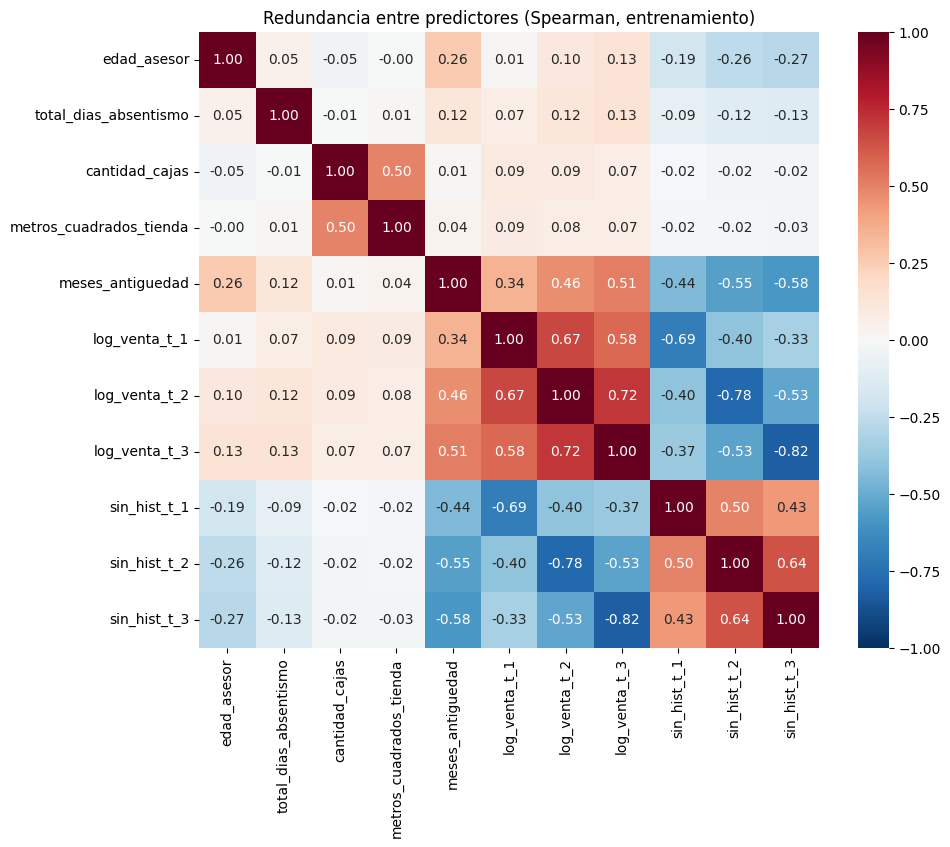

Pares con |r| ≥ 0.8:


,Variable A,Variable B,Spearman,|r|
51,log_venta_t_3,sin_hist_t_3,-0.82,0.82


,Variable A,Variable B,Spearman,|r|
51,log_venta_t_3,sin_hist_t_3,-0.82,0.82
47,log_venta_t_2,sin_hist_t_2,-0.78,0.78
45,log_venta_t_2,log_venta_t_3,0.72,0.72
42,log_venta_t_1,sin_hist_t_1,-0.69,0.69
40,log_venta_t_1,log_venta_t_2,0.67,0.67
54,sin_hist_t_2,sin_hist_t_3,0.64,0.64
39,meses_antiguedad,sin_hist_t_3,-0.58,0.58
41,log_venta_t_1,log_venta_t_3,0.58,0.58
38,meses_antiguedad,sin_hist_t_2,-0.55,0.55
50,log_venta_t_3,sin_hist_t_2,-0.53,0.53


In [20]:
## 4.2 Análisis de correlaciones para redundancia (solo entrenamiento)
import matplotlib.pyplot as plt                     # Gráficos
import seaborn as sns                               # Heatmap (viene instalado en Colab)

UMBRAL_REDUNDANCIA = 0.8                            # Criterio propio del proyecto
cols_red = NUMERICAS_MODELO + BINARIAS_MODELO       # 11 variables numéricas y binarias
corr = X_train[cols_red].corr(method='spearman')    # Matriz de correlación de Spearman (11 x 11)

fig, ax = plt.subplots(figsize=(10, 8))             # Lienzo del gráfico
sns.heatmap(corr, annot=True, fmt='.2f',            # Muestra el valor en cada celda
            cmap='RdBu_r', vmin=-1, vmax=1, ax=ax)  # Rojo = positiva, azul = negativa
ax.set_title('Redundancia entre predictores (Spearman, entrenamiento)')
fig.savefig(os.path.join(RUTA_SALIDAS, 'heatmap_redundancia.png'), dpi=120, bbox_inches='tight')   # Guarda en Drive
plt.show()

pares = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))   # Solo la mitad superior (sin repetir pares)
             .stack().reset_index())                # Convierte la matriz en lista de pares
pares.columns = ['Variable A', 'Variable B', 'Spearman']
pares['|r|'] = pares['Spearman'].abs()              # Fuerza de la relación, sin importar el signo
print(f'Pares con |r| ≥ {UMBRAL_REDUNDANCIA}:')
display(pares[pares['|r|'] >= UMBRAL_REDUNDANCIA].sort_values('|r|', ascending=False))
pares.sort_values('|r|', ascending=False).head(10)  # Los 10 pares más relacionados (referencia)

## 4.3 Método 1: correlaciones con el objetivo (irrelevancia)(solo entrenamiento)

In [21]:
## 4.3 Método 1: correlaciones con el objetivo (irrelevancia)(solo entrenamiento)
y_log = np.log1p(y_train)                           # Venta en log (reduce la asimetría para Pearson)

corr_y = pd.DataFrame({
    'Pearson': X_dum.corrwith(y_log, method='pearson'),     # Relación lineal con la venta
    'Spearman': X_dum.corrwith(y_log, method='spearman')})  # Relación monótona con la venta
corr_y['Variable'] = [c.split('=')[0] for c in corr_y.index]   # Dummy → variable original

corr_var = (corr_y.assign(absP=corr_y['Pearson'].abs(),       # Fuerza sin signo
                          absS=corr_y['Spearman'].abs())
                  .groupby('Variable')[['absP', 'absS']].max()   # Por variable: su dummy más fuerte
                  .rename(columns={'absP': '|Pearson|', 'absS': '|Spearman|'})
                  .sort_values('|Spearman|', ascending=False))  # Orden: más relevante primero
display(corr_var.round(3))                          # Ranking del Método 1

print('\nPar redundante (relación con la venta):')  # Se conserva la de mayor relación con el objetivo
corr_var.loc[['log_venta_t_3', 'sin_hist_t_3']].round(3)

,|Pearson|,|Spearman|
Variable,,
log_venta_t_1,0.26,0.61
log_venta_t_2,0.17,0.46
log_venta_t_3,0.15,0.40
edad_asesor,0.11,0.20
nacionalidad_asesor,0.22,0.19
mes_venta,0.08,0.17
marca,0.14,0.17
sin_hist_t_1,0.15,0.12
cantidad_cajas,0.06,0.10



Par redundante (relación con la venta):


,|Pearson|,|Spearman|
Variable,,
log_venta_t_3,0.15,0.40
sin_hist_t_3,0.07,0.04


# 4.4 Método 2: índice de ganancia = información mutua (solo entrenamiento)

In [22]:
# 4.4 Método 2: índice de ganancia = información mutua (solo entrenamiento)
from sklearn.feature_selection import mutual_info_regression   # Información mutua para objetivo continuo

X_mi = X_train.copy()                               # Copia para no alterar X_train
for c in CATEGORICAS_MODELO:                        # Categóricas → códigos enteros
    X_mi[c] = X_mi[c].cat.codes                     # 'MEDELLIN' → 7, etc.

DISCRETAS = BINARIAS_MODELO + CATEGORICAS_MODELO + [
    'total_dias_absentismo', 'cantidad_cajas', 'meses_antiguedad']   # Variables de valores enteros
mascara = [c in DISCRETAS for c in X_mi.columns]    # True = discreta (así lo exige el método)

mi = mutual_info_regression(X_mi, y_log,            # Información de cada variable sobre la venta
                            discrete_features=mascara,
                            random_state=42)        # # Semilla para reproducibilidad todo método con azar la usa
mi_var = pd.Series(mi, index=X_mi.columns,
                   name='Información mutua').sort_values(ascending=False)   # Ranking del Método 2
mi_var.round(4).to_frame()

,Información mutua
log_venta_t_1,0.53
log_venta_t_2,0.45
log_venta_t_3,0.39
metros_cuadrados_tienda,0.17
edad_asesor,0.09
mes_venta,0.06
zona_comercial,0.05
marca,0.04
meses_antiguedad,0.02
nacionalidad_asesor,0.02


## 4.5 Método 3: árbol de decisión (importancia de variables)
**Objetivo:** medir qué variables usa más el árbol para dividir los datos y reducir el error.

In [23]:
# 4.5 Método 3: árbol de decisión (solo entrenamiento)
from sklearn.tree import DecisionTreeRegressor      # Árbol para objetivo continuo

arbol = DecisionTreeRegressor(max_depth=8,          # Máximo 8 niveles de preguntas (evita memorizar)
                              min_samples_leaf=20,  # Cada hoja con al menos 20 registros
                              random_state=42) # Semilla
arbol.fit(X_dum, y_log)                             # Entrena con dummies y venta en log

imp = pd.Series(arbol.feature_importances_, index=X_dum.columns)   # Importancia de cada columna
imp_var = (imp.groupby([c.split('=')[0] for c in imp.index]).sum()  # Suma las dummies de cada variable
              .sort_values(ascending=False)
              .rename('Importancia (árbol)'))
print('Suma de importancias:', round(imp_var.sum(), 4))           # Esperado: 1.0
imp_var.round(4).to_frame()                         # Ranking del Método 3

Suma de importancias: 1.0


,Importancia (árbol)
log_venta_t_1,0.67
log_venta_t_2,0.12
edad_asesor,0.10
mes_venta,0.04
log_venta_t_3,0.02
meses_antiguedad,0.02
total_dias_absentismo,0.01
marca,0.01
metros_cuadrados_tienda,0.01
tipo_vinculacion,0.00


## 4.6 Método 4: regresión logística (coeficientes estandarizados)
**Objetivo:** medir qué variables distinguen mejor a los asesores de venta baja, media y alta.
**Sustento:** con variables escaladas, el tamaño del coeficiente indica cuánto influye cada variable en la probabilidad de pertenecer a cada grupo. Se toma el mayor |coeficiente| entre las 3 clases y, en las categóricas, entre sus dummies (criterio propio).

In [24]:
# 5.6 Método 4: regresión logística (solo entrenamiento)
from sklearn.preprocessing import StandardScaler    # Escalado: media 0, desviación 1
from sklearn.linear_model import LogisticRegression # Clasificador de clases
from sklearn.pipeline import make_pipeline          # Encadena escalado + modelo (escala solo con lo que entrena)

y_terc = pd.qcut(y_train, q=3, labels=['baja', 'media', 'alta'])   # Venta → 3 grupos iguales (terciles)
print('Tamaño de cada grupo:\n', y_terc.value_counts())            # Esperado: tamaños casi iguales

logit = make_pipeline(StandardScaler(),             # 1.° escala las 45 columnas
                      LogisticRegression(max_iter=2000,             # Más iteraciones para que converja
                                         random_state= 42 ))     # Semilla
logit.fit(X_dum, y_terc)                            # Entrena: variables → grupo de venta

coef = pd.DataFrame(logit[-1].coef_,                # Coeficientes: una fila por clase (baja, media, alta)
                    columns=X_dum.columns, index=logit[-1].classes_)
coef_abs = coef.abs().max(axis=0)                   # Por columna: su mayor |coef| entre las 3 clases
log_var = (coef_abs.groupby([c.split('=')[0] for c in coef_abs.index]).max()   # Por variable: su dummy más fuerte
                   .sort_values(ascending=False)
                   .rename('|Coef. estandarizado| máx'))
log_var.round(3).to_frame()                         # Ranking del Método 4

Tamaño de cada grupo:
 valor_venta_asesor_mes_t
baja     4374
alta     4374
media    4373
Name: count, dtype: int64


,|Coef. estandarizado| máx
log_venta_t_1,6.73
sin_hist_t_2,6.61
log_venta_t_2,6.52
sin_hist_t_1,6.42
sin_hist_t_3,5.16
log_venta_t_3,5.09
total_dias_absentismo,0.51
mes_venta,0.42
meses_antiguedad,0.17
edad_asesor,0.16


## 4.7 Votación de los 4 métodos
**Objetivo:** decidir qué variables se quedan, combinando los 4 métodos.
**Sustento (criterio propio del proyecto):** cada método vota por sus 10 variables más importantes; se selecciona la variable con 2 o más votos de 4. Así ninguna decisión depende de un solo método. sin_hist_t_3 se excluye por redundancia, sin importar sus votos.

In [25]:
# 4.7 Votación de los 4 métodos
TOP = 10                                            # Cada método vota por sus 10 mejores
rankings = {'Correlación (Spearman)': corr_var['|Spearman|'],       # Método 1 (Celda 5.3)
            'Índice de ganancia (IM)': mi_var,                      # Método 2 (Celda 5.4)
            'Árbol de decisión': imp_var,                           # Método 3 (Celda 5.5)
            'Regresión logística': log_var}                         # Método 4 (Celda 5.6)

votos = pd.DataFrame({m: s.rank(ascending=False, method='first')    # Puesto en el ranking (1 = mejor), sin redondear
                          .le(TOP).astype(int)                      # 1 si está en el top 10, 0 si no
                      for m, s in rankings.items()})
votos['Total votos'] = votos.sum(axis=1)            # Suma de votos (0 a 4)

EXCLUIDAS_REDUNDANCIA = ['sin_hist_t_3']            # Decidido en la Fase 5A/5B
votos['Decisión'] = np.where(votos.index.isin(EXCLUIDAS_REDUNDANCIA), 'Excluida (redundante)',
                    np.where(votos['Total votos'] >= 2, 'Seleccionada', 'Excluida (irrelevante)'))
votos = votos.sort_values('Total votos', ascending=False)   # Las más votadas arriba
print('Seleccionadas:', (votos['Decisión'] == 'Seleccionada').sum(), 'de', len(votos))
votos                                               # Tabla de votos (va al formato)

Seleccionadas: 11 de 18


,Correlación (Spearman),Índice de ganancia (IM),Árbol de decisión,Regresión logística,Total votos,Decisión
edad_asesor,1,1,1,1,4,Seleccionada
log_venta_t_1,1,1,1,1,4,Seleccionada
log_venta_t_3,1,1,1,1,4,Seleccionada
log_venta_t_2,1,1,1,1,4,Seleccionada
mes_venta,1,1,1,1,4,Seleccionada
meses_antiguedad,0,1,1,1,3,Seleccionada
metros_cuadrados_tienda,1,1,1,0,3,Seleccionada
marca,1,1,1,0,3,Seleccionada
total_dias_absentismo,0,0,1,1,2,Seleccionada
nacionalidad_asesor,1,1,0,0,2,Seleccionada


In [26]:
# 4.8 Guardado de resultados
import json                                         # Para guardar la lista en formato JSON

sel = votos.index[votos['Decisión'] == 'Seleccionada'].tolist()    # Variables ganadoras
seleccion = {'numericas':   [v for v in NUMERICAS_MODELO if v in sel],     # Separadas por tipo
             'binarias':    [v for v in BINARIAS_MODELO if v in sel],      # (el Pipeline las trata distinto)
             'categoricas': [v for v in CATEGORICAS_MODELO if v in sel],
             'objetivo':    OBJETIVO}
with open(os.path.join(RUTA_SALIDAS, 'variables_seleccionadas.json'), 'w', encoding='utf-8') as f:
    json.dump(seleccion, f, ensure_ascii=False, indent=2)   # Guarda la lista en Drive

columnas = sel + [OBJETIVO, 't', 'anio_venta', 'venta_t_1']   # Solo lo necesario para el Notebook 2
df_feat[columnas].to_csv(os.path.join(RUTA_SALIDAS, 'base_modelo.csv'), index=False)   # Base completa (train + test)

print('Variables seleccionadas:', json.dumps(seleccion, ensure_ascii=False, indent=2))
print('base_modelo.csv:', df_feat[columnas].shape)  # 17603 filas × (seleccionadas + 4)

Variables seleccionadas: {
  "numericas": [
    "edad_asesor",
    "total_dias_absentismo",
    "metros_cuadrados_tienda",
    "meses_antiguedad",
    "log_venta_t_1",
    "log_venta_t_2",
    "log_venta_t_3"
  ],
  "binarias": [
    "sin_hist_t_1"
  ],
  "categoricas": [
    "nacionalidad_asesor",
    "marca",
    "mes_venta"
  ],
  "objetivo": "valor_venta_asesor_mes_t"
}
base_modelo.csv: (17603, 15)
